In [1]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"]="-1"    

import numpy as np
import gym
from gym import spaces
import tensorflow as tf
import time
import pandas as pd
import ta
from tqdm import tqdm
import random
import pickle
from collections import deque

y = 4*24*365

In [2]:
seq_len = int(4*24*2)
order_value = 1000
idp = 0.001/100/100
comission = 25/100000
    
log_interval = 4*24

In [3]:
def sample_to_x_y(sample):
        
                current_close = sample[-1].c

                prev_close = [candle.c for candle in sample]
                prev_high = [candle.h for candle in sample]
                prev_low = [candle.l for candle in sample]

                prev_sma21 = [candle.sma21 for candle in sample]
                #prev_sma50 = [candle.sma50 for candle in sample]
                prev_sma200 = [candle.sma200 for candle in sample]
                
                #dl = [candle.dl for candle in sample]
                #dh = [candle.dh for candle in sample]

                #dl_relative = [-(current_close - dl[o]) / dl[o] for o in range(seq_len)]
                #dh_relative = [-(current_close - dh[o]) / dh[o] for o in range(seq_len)]
                
                prev_sma21_relative = [-(current_close - prev_sma21[o]) / prev_sma21[o] for o in range(seq_len)]
                #prev_sma50_relative = [-(current_close - prev_sma50[o]) / prev_sma50[o] for o in range(seq_len)]
                prev_sma200_relative = [-(current_close - prev_sma200[o]) / prev_sma200[o] for o in range(seq_len)]

                prev_close_relative = [-(current_close - prev_close[o]) / prev_close[o] for o in range(seq_len)]
                prev_high_relative = [-(current_close - prev_high[o]) / prev_high[o] for o in range(seq_len)]
                prev_low_relative = [-(current_close - prev_low[o]) / prev_low[o] for o in range(seq_len)]

                maxval = max(prev_high_relative)
                minval = min(prev_low_relative)
                
                scale = 1 / (sample[-1].atr_value / sample[-1].c) # / (maxval - minval)
                #scale = 1 / (maxval - minval)

                prev_sma21_relative_scaled = [i * scale for i in prev_sma21_relative]
                #prev_sma50_relative_scaled = [i * scale for i in prev_sma50_relative]
                prev_sma200_relative_scaled = [i * scale for i in prev_sma200_relative]

                prev_close_relative_scaled = [i * scale for i in prev_close_relative]
                prev_low_relative_scaled = [i * scale for i in prev_low_relative]
                prev_high_relative_scaled = [i * scale for i in prev_high_relative]

                #dl_rel_scaled = [i * scale for i in dl_relative]
                #dh_rel_scaled = [i * scale for i in dh_relative]
                
                prev_rsi_14 = [candle.rsi14 for candle in sample]


                x = []
                for o in range(len(prev_close)):
                    ts = []
                    ts.append(prev_close_relative_scaled[o])
                    ts.append(prev_high_relative_scaled[o])
                    ts.append(prev_low_relative_scaled[o])

                    ts.append(prev_sma21_relative_scaled[o])
                    #ts.append(prev_sma50_relative_scaled[o])
                    ts.append(prev_sma200_relative_scaled[o])
                    
                    #ts.append(dh_rel_scaled[o])
                    #ts.append(dl_rel_scaled[o])
                    
                    ts.append(prev_rsi_14[o])

                    x.append(ts)

                x = np.array(x)
                return x
        

In [4]:
class candle_class:
    pass
    
df_objects = 0
def create_candles(df_list):
    df_objects = []
    for ind, df in tqdm(enumerate(df_list)):
        sma21_raw = list(ta.trend.SMAIndicator(df["CLOSE"], 21).sma_indicator())
        #sma50_raw = list(ta.trend.SMAIndicator(df["CLOSE"], 50).sma_indicator())
        sma200_raw = list(ta.trend.SMAIndicator(df["CLOSE"], 200).sma_indicator())
        rsi_14 = [x / 50 - 1 for x in list(ta.momentum.RSIIndicator(df["CLOSE"], 14).rsi())]
        atr_value = list(ta.volatility.AverageTrueRange(df["HIGH"], df["LOW"], df["CLOSE"], 200).average_true_range())
        #atr_fast = list(ta.volatility.AverageTrueRange(df["HIGH"], df["LOW"], df["CLOSE"], 9).average_true_range())
        #donchi = ta.volatility.DonchianChannel(df["HIGH"], df["LOW"], df["CLOSE"], 21)
        #dh = list(donchi.donchian_channel_hband())
        #dl = list(donchi.donchian_channel_lband())

        candles = []
        for i in range(len(df)):
          new_candle = candle_class()
          #new_candle.t = i
          #new_candle.o = df.iloc[i]["OPEN"]
          new_candle.h = df.iloc[i]["HIGH"]
          new_candle.l = df.iloc[i]["LOW"]
          new_candle.c = df.iloc[i]["CLOSE"]


          #new_candle.dh = dh[i]
          #new_candle.dl = dl[i]
          new_candle.sma21 = sma21_raw[i]
          #new_candle.sma50 = sma50_raw[i]
          new_candle.sma200 = sma200_raw[i]
          new_candle.rsi14 = rsi_14[i]
          new_candle.atr_value = atr_value[i]
          #new_candle.atr_fast = atr_fast[i]

          candles.append(new_candle)
        
        df_objects.append(candles)
    return df_objects
  
class environment(gym.Env):

  def __init__(self):
    super(environment, self).__init__()
    self.rs = 0


  def _next_observation(self):
            candles = df_objects[self.rs][self.current_step - seq_len + 1:self.current_step + 1]
            
            inference_data = sample_to_x_y(candles)
            
            return inference_data, np.array([self.position, self.current_win])

  
  def reset(self, first_reset = False):
    self.past_positions = [0 for _ in range(seq_len)]
    self.rs += 1
    if self.rs > len(df_objects)-1:
        self.rs = 0
    
    
    self.current_step = 200+seq_len if first_reset == False else random.randint(200+seq_len,len(df_objects[self.rs]) - 1000)
    
    self.position = 0
    self.entry_price = 0
    self.win = 0
    self.current_win = 0
    self.startindex = self.current_step
    self.last_reward = 0
    self.entry_time = 0
    self.reward_since_last_log = 0

    return self._next_observation()

  
  def close(self):
        self.win -= comission * order_value / 2
        self.position = 0
        self.win+=self.current_win
        self.current_win = 0
        
        
  def entry(self):
        self.entry_price = df_objects[self.rs][self.current_step].c
        self.win -= comission * order_value / 2

  def step(self, action):
    global ep_len
    
    if action == 0:
        self.win-=idp*order_value
        if self.position != 0:
            self.close()
        pass
    
    if action == 1:
      #short
      if self.position == 1:
        self.close()

      if self.position == -1:
        pass
      else:
        self.position = -1
        self.entry()
        
    if action == 2:
      #long
      if self.position == -1:
        self.close()

      if self.position == 1:
        pass
      else:
        self.position = 1
        self.entry()
        
    self.past_positions.append(self.position)
    del self.past_positions[0]
    
    self.current_step += 1
    if self.position != 0:
      current_price = df_objects[self.rs][self.current_step].c
      entry = self.entry_price
      diff = (current_price - entry) / entry * order_value

      if self.position == 1:
        self.current_win = diff
      if self.position == -1:
        self.current_win = -diff

    reward_raw = self.win + self.current_win
    reward = reward_raw - self.last_reward
    self.last_reward = reward_raw
    
    done = self.current_step == len(df_objects[self.rs]) -1
    
    if (self.current_step - self.startindex) % log_interval == 0:
        log_reward = reward_raw - self.reward_since_last_log
        self.reward_since_last_log = reward_raw 
        file2 = open("r2_log.txt", "a")  
        file2.write(str(log_reward))
        file2.write("\n")
        file2.close()
        
    
    obs = self._next_observation()
    return obs, reward, done


def load_files():
    files = os.listdir("./archive/")
    df_list = []
    for i in files:
        if "2000-2020" in i:
            df_list.append(pd.read_csv("./archive/"+i))

    df_list2 = df_list[:]
    for i in df_list2:
        d = {
            "DATE_TIME": list(i["DATE_TIME"]),
            "HIGH": [1 / x for x in list(i["LOW"])],
            "LOW": [1 / x for x in list(i["HIGH"])],
            "OPEN": [1 / x for x in list(i["OPEN"])],
            "CLOSE": [1 / x for x in list(i["CLOSE"])],
        }
        df_list.append(pd.DataFrame(d))
    return df_list

def Save(ob, file):
    f = open(file, "wb")
    pickle.dump(ob, f)
    f.close()
def Load(file):
    f = open(file, "rb")
    obj = pickle.load(f)
    f.close()
    return obj

In [5]:
class_name = "candles_s.cla"
#class_name = "candle_single.cla"
overwrite = False

if os.path.exists(class_name) and not overwrite:
    print("loading candles...")
    df_objects = Load(class_name)
else:
    print("preparing df-objects...")
    df_list = load_files()
    df_objects = create_candles(df_list)
    #df_objects = create_candles([df_list[i][0:10000] for i in range(len(df_list))])
    Save(df_objects, class_name)

loading candles...


In [6]:
class TransformerBlock(tf.keras.layers.Layer):
    embed_dim = 0
    num_heads = 0
    ff_dim = 0 
    rate=0
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate


        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential(
            [tf.keras.layers.Dense(ff_dim, activation="relu"), tf.keras.layers.Dense(embed_dim),]
        )
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def get_config(self):
        cfg = super().get_config()
        cfg.update()
        cfg.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'ff_dim': self.ff_dim,
            'rate': self.rate,
        })
        return cfg  
    def call(self, inputs, training = False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    
def getPositionEncoding(seq_len, d, n=10000):
    P = np.zeros((seq_len, d))
    for k in range(seq_len):
        for i in np.arange(int(d/2)):
            denominator = np.power(n, 2*i/d)
            P[k, 2*i] = np.sin(k/denominator)
            P[k, 2*i+1] = np.cos(k/denominator)
    return P[::]

class Positions(tf.keras.layers.Layer):
    P = []
    d = 0
    seq_len = 0
    def __init__(self, seq_len, d, **kwargs):
        super(Positions, self).__init__()
        self.seq_len = seq_len
        self.d = d
        self.p = getPositionEncoding(seq_len, d)
        

    def call(self, x):
        return x + self.p

    def get_config(self):
        cfg = super().get_config()
        cfg.update()
        cfg.update({
            'p': self.p,
            'seq_len': self.seq_len,
            'd': self.d
        })
        return cfg  


In [7]:
class DQNAgent:
    def __init__(self, model, n_actions, memory_size = 10000, p_exploration_start = 1,optimizer = tf.keras.optimizers.Adam(0.0005), p_exploration_decay_factor = 0.9999, gamma = 0.99, batch_size =32, name = "dqn1", target_model_sync = 1000):
        self.target_model_sync = target_model_sync
        self.gamma = gamma
        self.n_actions = n_actions
        self.batch_size = batch_size
        self.model = model
        self.name = name
        self.memory_size = memory_size
        self.optimizer = optimizer
        self.p_exploration = p_exploration_start
        self.p_exploration_decay_factor = p_exploration_decay_factor
        self.m1 = np.eye(self.n_actions)
        self.target_model = tf.keras.models.clone_model(self.model)
        self.total_steps_trained = 0
        
        
        self.memory = deque(maxlen = self.memory_size)
        
    def copy_weights(self):
        self.target_model.set_weights(self.model.get_weights())
        
    def load_weights(self):
        self.model.load_weights(self.name)
    def save_weights(self):
        self.model.save_weights(self.name, overwrite = True)
        
    def select_actions(self, current_states, positions, training = False):
        if training:
            self.p_exploration *= self.p_exploration_decay_factor
            if np.random.uniform(0,1) < self.p_exploration:
                return [np.random.choice(range(self.n_actions)) for _ in range(np.array(current_states).shape[0])]
            
        q_values = self.model([current_states, positions])
        return [np.argmax(i) for i in q_values]
        
    def observe_sasrt(self, state, action, next_state, reward, terminal):
        self.memory.append([state, action, reward, terminal, next_state])
        
        
    def tstep(self, x, y, masks):
        with tf.GradientTape() as t:
            estimated_q_values = tf.math.reduce_sum(self.model(x, training=True) * masks, axis=1)
            loss = tf.keras.losses.mean_squared_error(y, estimated_q_values)
        
        gradient = t.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(gradient, self.model.trainable_variables))
        return loss
        
    def update_parameters(self):
        if len(self.memory) < self.batch_size:
            return 0, 0
        
        sarts_batch = random.sample(self.memory, self.batch_size)
        
        states = [x[0] for x in sarts_batch]
        states_1 = np.array([x[0] for x in states])
        states_2 = np.array([x[1] for x in states])
        
        actions = [x[1] for x in sarts_batch]
        rewards = [x[2] for x in sarts_batch]
        terminals = [x[3] for x in sarts_batch]
        
        next_states = [x[4] for x in sarts_batch]
        next_states_1 = np.array([x[0] for x in next_states])
        next_states_2 = np.array([x[1] for x in next_states])
        
        masks = self.m1[actions]
        
        estimated_q_values_next = self.target_model([next_states_1, next_states_2])
        q_batch = np.max(estimated_q_values_next, axis=1).flatten()
        target_q_values = np.array([rewards[i] + self.gamma*q_batch[i] if terminals[i] == False else rewards[i] for i in range(self.batch_size)], dtype="float32")
        
        loss = self.tstep([states_1, states_2], target_q_values, masks)
        
        self.total_steps_trained+=1
        if self.total_steps_trained % self.target_model_sync == 0:
            self.copy_weights()
       
        return np.mean(loss), np.mean(estimated_q_values_next)
    
    
    def train(self, num_steps, envs, log_interval = 1000, warmup = 0, train_steps_per_step = 1):
        total_steps = 0
        num_envs = len(envs)
        states = [x.reset(True) for x in envs]
        
        
        total_rewards = []
        losses = [0]
        q_v = [0]
        
        current_episode_reward_sum = 0
        
        for i in range(num_steps):
            total_steps+=1

            if i % log_interval == 0:
                progbar = tf.keras.utils.Progbar(log_interval, interval=0.05, stateful_metrics = ["reward sum"])
            if (i+1) % log_interval == 0:
                self.save_weights()
                file = open("loss_log.txt", "a")  
                for loss in losses:
                    file.write(str(loss))
                    file.write("\n")
                file.close()
                
                file = open("qv_log.txt", "a")  
                for qv in q_v:
                    file.write(str(qv))
                    file.write("\n")
                file.close()
                
                file = open("rewards_log.txt", "a")  
                for total_reward in total_rewards:
                    file.write(str(total_reward))
                    file.write("\n")
                file.close()
                
                total_rewards = []
                losses = [0]
                q_v = [0]
            
            
            
            states_1 = np.array([x[0] for x in states])
            states_2 = np.array([x[1] for x in states])
            actions = self.select_actions(states_1, states_2, training=True)
            returns = []
            for o in range(num_envs):
                returns.append(envs[o].step(actions[o]))

            sasrt_pairs = []
            for index, sample in enumerate(returns):
                sasrt_pairs.append([states[index], actions[index]]+[x for x in sample])

            next_states = [x[2] for x in sasrt_pairs]
                
            reward = [x[3] for x in sasrt_pairs]
            current_episode_reward_sum += np.sum(reward)
            
            total_rewards.extend(reward)
            
            for index, o in enumerate(sasrt_pairs):
                #print(o)
                if o[4] == True:
                    next_states[index] = envs[index].reset()
                self.observe_sasrt(o[0], o[1], o[2], o[3], o[4])
    
            states = next_states
            if total_steps > warmup:
                for _ in range(train_steps_per_step):
                    loss, q = self.update_parameters()
                    losses.append(loss)
                    q_v.append(q)
            else:
                loss, q = 0, 0
            
            progbar.update(i%log_interval+1, values = [("loss", np.mean(losses[-train_steps_per_step:])), ("mean q", np.mean(q_v[-train_steps_per_step:])), ("rewards", np.mean(reward)), ("reward sum", current_episode_reward_sum)])
       

In [8]:
tf.keras.backend.clear_session()

# Next, we build a very simple model.
inputs_1 = tf.keras.layers.Input(shape = (seq_len, 6))
inputs_pos = tf.keras.layers.Input(shape = (2))

x = tf.keras.layers.Reshape((seq_len,6))(inputs_1)

x2 = tf.keras.layers.Conv1D(64,5, padding="same")(x)
x2 = tf.keras.layers.LeakyReLU(alpha=0.1)(x2)
x = tf.keras.layers.Concatenate()([x,x2])

x = tf.keras.layers.Dense(64)(x)
x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

x = tf.keras.layers.Dense(16)(x)
x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

x2 = tf.keras.layers.Conv1D(64,3, padding="same")(x)
x2 = tf.keras.layers.LeakyReLU(alpha=0.1)(x2)
x = tf.keras.layers.Concatenate()([x,x2])

x = tf.keras.layers.Dense(64)(x)
x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

x = tf.keras.layers.Dense(32)(x)
x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

#x = Positions(seq_len, x.shape[-1])(x)
#x = TransformerBlock(x.shape[2], 12, 128)(x)

x = tf.keras.layers.LSTM(128, activation = "tanh", return_sequences = True)(x)
x = tf.keras.layers.LSTM(64, activation = "tanh", return_sequences = False)(x)
#x = tf.keras.layers.Flatten()(x)

x = tf.keras.layers.Concatenate()([inputs_pos, x])

x = tf.keras.layers.Dense(128)(x)
x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

x = tf.keras.layers.Dense(128)(x)
x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

x = tf.keras.layers.Dense(64)(x)
x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
        
outputs = tf.keras.layers.Dense(3, activation = "linear", use_bias=False)(x)
model = tf.keras.Model([inputs_1,inputs_pos], outputs)
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 192, 6)]     0                                            
__________________________________________________________________________________________________
reshape (Reshape)               (None, 192, 6)       0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1d (Conv1D)                 (None, 192, 64)      1984        reshape[0][0]                    
__________________________________________________________________________________________________
leaky_re_lu (LeakyReLU)         (None, 192, 64)      0           conv1d[0][0]                     
______________________________________________________________________________________________

In [9]:
agent = DQNAgent(
    model = model, 
    n_actions = 3, 
    memory_size = y*30, 
    gamma=0.985,
    p_exploration_decay_factor = 1,# 0.9999,
    p_exploration_start = 0.01,
    optimizer = tf.keras.optimizers.Adam(0.00025, clipvalue = 1.0), 
    batch_size = 512, 
    target_model_sync = 200, 
    name="relearn4.0")
agent.load_weights()

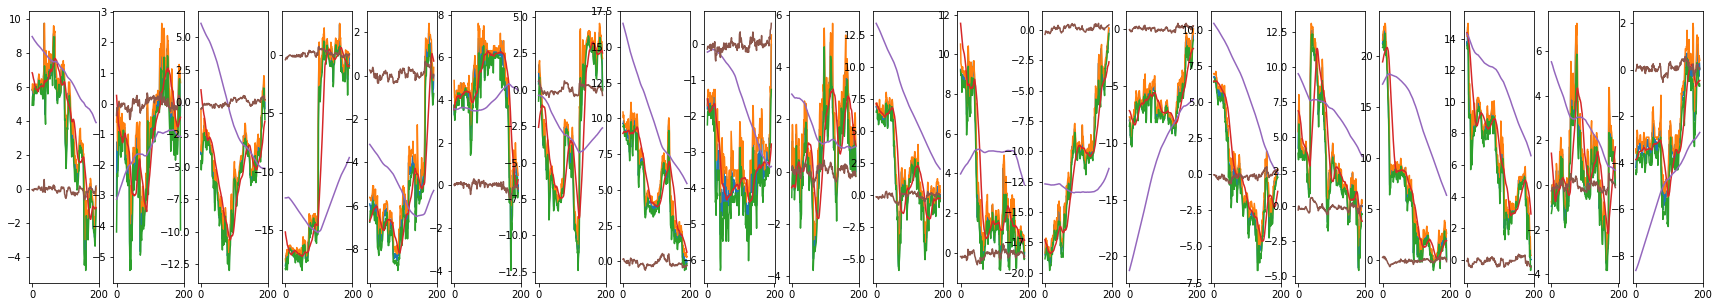

In [29]:
num_parallel = 20
envs = [environment() for _ in range(num_parallel)]
for i,e in enumerate(envs):
    e.rs+=int(i*14/num_parallel)
    
if True:
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(1,num_parallel,figsize=(30,5))

    for o in range(num_parallel):
        x = envs[o].reset(True)[0]
        x_ = np.transpose(x)
        for i in x_:
            ax[o].plot(i) if num_parallel > 1 else ax.plot(i) 

In [30]:
n = y*1
agent.train(num_steps = n, envs = envs, warmup = y*1, log_interval = y, train_steps_per_step=1)

35040/35040 [==============================] - 2661s 76ms/step - loss: 0.0000e+00 - mean q: 0.0000e+00 - rewards: -0.0056 - reward sum: -3913.1990


In [31]:
len(agent.memory)

710502

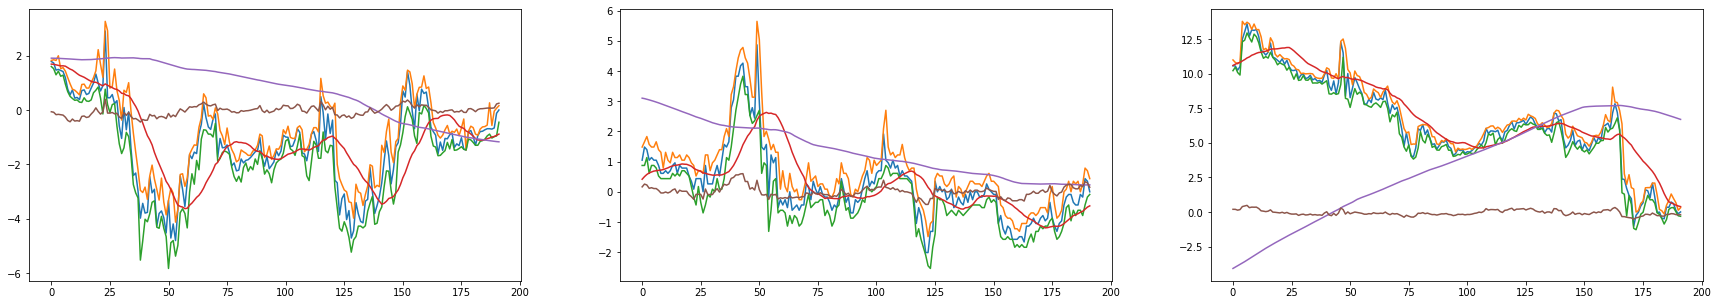

In [32]:
num_parallel = 3
envs = [environment() for _ in range(num_parallel)]
for i,e in enumerate(envs):
    e.rs+=int(i*14/num_parallel)

if True:
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(1,num_parallel,figsize=(30,5))

    for o in range(num_parallel):
        x = envs[o].reset(True)[0]
        x_ = np.transpose(x)
        for i in x_:
            ax[o].plot(i) if num_parallel > 1 else ax.plot(i) 

In [ ]:
n = y*500
agent.train(num_steps = n, envs = envs, warmup = 0, log_interval = y, train_steps_per_step=1)

19223/35040 [===============>..............] - ETA: 56:05 - loss: 0.4696 - mean q: 0.5428 - rewards: -0.0040 - reward sum: -3921.1307

In [ ]:
agent.save_weights()

In [ ]:
#https://youtu.be/uD4izuDMUQA